In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [16]:
data = pd.read_csv("D:\\linear regression\\Real estate.csv")
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [37]:
# Create new features
df_engineered = data.copy()

df_engineered['distance_to_city_center'] = np.sqrt(
    (df_engineered['X5 latitude'] - df_engineered['X5 latitude'].min())**2 +
    (df_engineered['X6 longitude'] - df_engineered['X6 longitude'].min())**2
)

df_engineered['accessibility_score'] = (
    df_engineered['X4 number of convenience stores'] / 
    (df_engineered['X3 distance to the nearest MRT station'] + 1)  # +1 to avoid division by zero
)

df_engineered['age_category'] = pd.cut(
    df_engineered['X2 house age'], 
    bins=[-1, 5, 15, 30, 50],
    labels=['new', 'young', 'middle', 'old']
)

df_engineered['high_store_density'] = (df_engineered['X4 number of convenience stores'] >= 5).astype(int)

df_engineered['transaction_month'] = df_engineered['X1 transaction date'].dt.month
df_engineered['transaction_season'] = ((df_engineered['X1 transaction date'].dt.month - 1) // 3).astype(int)

df_engineered = pd.get_dummies(df_engineered, columns=['age_category'], drop_first=True)

In [38]:
df_engineered.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,distance_to_city_center,accessibility_score,high_store_density,transaction_month,transaction_season,age_category_young,age_category_middle,age_category_old
0,1,2012-11-01,32.0,84.87882,10,24.98298,121.54024,37.9,0.083917,0.116443,1,11,3,False,False,True
1,2,2012-11-01,19.5,306.59470,9,24.98034,121.53951,42.2,0.081752,0.029259,1,11,3,False,True,False
2,3,2013-07-01,13.3,561.98450,5,24.98746,121.54391,47.3,0.089562,0.008881,1,7,2,True,False,False
3,4,2013-06-01,13.3,561.98450,5,24.98746,121.54391,54.8,0.089562,0.008881,1,6,1,True,False,False
4,5,2012-10-01,5.0,390.56840,5,24.97937,121.54245,43.1,0.083590,0.012769,1,10,3,False,False,False


In [39]:
df_engineered.columns.tolist()

['No',
 'X1 transaction date',
 'X2 house age',
 'X3 distance to the nearest MRT station',
 'X4 number of convenience stores',
 'X5 latitude',
 'X6 longitude',
 'Y house price of unit area',
 'distance_to_city_center',
 'accessibility_score',
 'high_store_density',
 'transaction_month',
 'transaction_season',
 'age_category_young',
 'age_category_middle',
 'age_category_old']

In [40]:
df_engineered.shape[1]

16

In [53]:
# Define features (X) and target (y)
# Drop 'No' (ID), 'Y house price of unit area' (target), and 'X1 transaction date' (datetime - not needed, we have month/season)
X = df_engineered.drop(['No', 'Y house price of unit area', 'X1 transaction date'], axis=1)
y = df_engineered['Y house price of unit area']

print(f"\nNumber of features: {X.shape[1]}")
print(f"Features: {X.columns.tolist()}")


Number of features: 13
Features: ['X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'distance_to_city_center', 'accessibility_score', 'high_store_density', 'transaction_month', 'transaction_season', 'age_category_young', 'age_category_middle', 'age_category_old']


In [58]:
# Detect and remove outliers using IQR method
print("Original data shape:", df_engineered.shape)

# Calculate IQR for target variable
Q1 = df_engineered['Y house price of unit area'].quantile(0.25)
Q3 = df_engineered['Y house price of unit area'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nOutlier bounds for house price:")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

# Identify outliers
outliers = (df_engineered['Y house price of unit area'] < lower_bound) | (df_engineered['Y house price of unit area'] > upper_bound)
print(f"\nNumber of outliers found: {outliers.sum()}")

# Remove outliers
df_engineered = df_engineered[~outliers]
print(f"Data shape after removing outliers: {df_engineered.shape}")


Original data shape: (411, 16)

Outlier bounds for house price:
Lower bound: -0.70
Upper bound: 74.50

Number of outliers found: 0
Data shape after removing outliers: (411, 16)


In [60]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

In [64]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (L2)': Ridge(alpha=1.0),
    'Lasso Regression (L1)': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    
    model.fit(x_train_scaled, y_train)
    
    
    y_pred = model.predict(x_test_scaled)
    
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    cv_scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='r2')
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'CV R2 Mean': cv_scores.mean(),
        'CV R2 Std': cv_scores.std(),
        'model': model
    }
    
    print(f"\n{name}:")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  CV R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")


Linear Regression:
  MSE: 75.04
  RMSE: 8.66
  MAE: 5.73
  R²: 0.4598
  CV R²: 0.6951 (±0.0714)

Ridge Regression (L2):
  MSE: 73.23
  RMSE: 8.56
  MAE: 5.63
  R²: 0.4728
  CV R²: 0.6978 (±0.0627)

Lasso Regression (L1):
  MSE: 72.38
  RMSE: 8.51
  MAE: 5.55
  R²: 0.4789
  CV R²: 0.6980 (±0.0598)

Random Forest:
  MSE: 56.16
  RMSE: 7.49
  MAE: 5.19
  R²: 0.5957
  CV R²: 0.8096 (±0.0442)

Gradient Boosting:
  MSE: 52.70
  RMSE: 7.26
  MAE: 4.78
  R²: 0.6206
  CV R²: 0.8057 (±0.0472)


In [65]:
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = results[best_model_name]
print("\n" + "="*50)
print(f"BEST MODEL: {best_model_name}")
print("="*50)
print(f"R² Score: {best_model['R2']:.4f}")
print(f"RMSE: {best_model['RMSE']:.2f}")
print(f"MAE: {best_model['MAE']:.2f}")


BEST MODEL: Gradient Boosting
R² Score: 0.6206
RMSE: 7.26
MAE: 4.78


In [67]:
# Get predictions from the best model
best_model_object = results[best_model_name]['model']
y_pred_best = best_model_object.predict(x_test_scaled)

print(f"\nBest model predictions generated for visualization")



Best model predictions generated for visualization


In [74]:
# Use best model for predictions
best_model_obj = results[best_model_name]['model']
y_pred_best = best_model_obj.predict(x_test_scaled)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Error': y_test.values - y_pred_best,
    'Error_Percentage': ((y_test.values - y_pred_best) / y_test.values) * 100
})

print("\nPrediction Statistics:")
print(f"Mean Absolute Error: {comparison_df['Error'].abs().mean():.2f}")
print(f"Mean Absolute Percentage Error: {comparison_df['Error_Percentage'].abs().mean():.2f}%")
print(f"Max Overprediction: {comparison_df['Error'].min():.2f}")
print(f"Max Underprediction: {comparison_df['Error'].max():.2f}")


Prediction Statistics:
Mean Absolute Error: 4.78
Mean Absolute Percentage Error: 17.16%
Max Overprediction: -30.31
Max Underprediction: 29.99


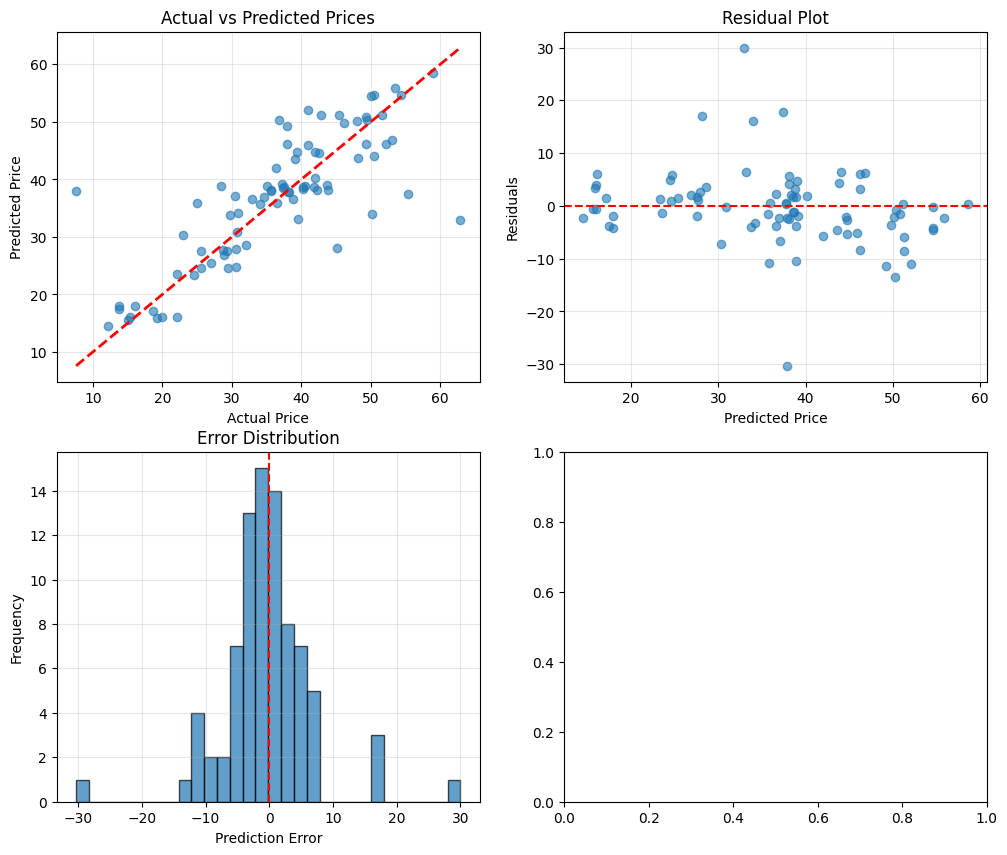

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plot: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_best, alpha=0.6)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title('Actual vs Predicted Prices')
axes[0, 0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred_best
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.6)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Price')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Error distribution
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Prediction Error')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Error Distribution')
axes[1, 0].grid(True, alpha=0.3)